# Set 12 - Test auf echten Daten: tägliche Fahrrad-Ausleihen

**Lernziele:** Eine echte Zeitreihe prüfen, einen Prognosezeitpunkt festlegen, Muster nur in der Trainingshistorie untersuchen und ein Modell gegen saisonale Baselines testen.

Die lokale Datei enthält tägliche Ausleihzahlen von Capital Bikeshare (2011–2012). Quelle: Hadi Fanaee-T, [UCI Bike Sharing](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset), DOI [10.24432/C5W894](https://doi.org/10.24432/C5W894). Lizenz: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/), kommerzielle Nutzung mit Quellenangabe erlaubt. Die Originaldatei `day.csv` wurde nur in `bike_day.csv` umbenannt.

**Aufgabe:** Vor Beginn eines Tages dessen Gesamtzahl an Ausleihen schätzen. Die Werte bis gestern und der Kalender sind bekannt. Wir verwenden keine tatsächlichen Wetterwerte des Zieltags. Die Komponenten `casual` und `registered` summieren sich zu `cnt` und wären als Eingangsmerkmale ein Ziel-Leak.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

kandidaten = [Path.cwd(), *Path.cwd().parents]
set_ordner = next((p for basis in kandidaten
                   for p in (basis, basis / "set12-zeitreihenanalyse")
                   if (p / "zeitreihen_tools.py").exists()), None)
if set_ordner is None:
    raise FileNotFoundError("Notebook bitte innerhalb des Kursordners starten.")
if str(set_ordner) not in sys.path:
    sys.path.insert(0, str(set_ordner))
from zeitreihen_tools import (FARBEN, plot_stil, zeitachse, synthetische_reihe,
                              lag_tabelle, metriken, lade_bike, lade_energie)
plot_stil()

In [2]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.base import clone

bike = lade_bike()
y = bike.cnt.astype(float)
train_ende = pd.Timestamp("2012-06-30")
val_ende = pd.Timestamp("2012-10-31")
train_roh = y.loc[:train_ende]
print("Zeitreihe:",len(y),"Tage; Raster:",y.index.freqstr)
print("Fehlende Werte:",int(y.isna().sum()),"Doppelte Zeitpunkte:",y.index.has_duplicates)
print("Chronologischer Plan: Training bis 30.06.2012, Validierung Juli–Oktober, Test November–Dezember.")
display(bike.loc[:train_ende].head())

Zeitreihe: 731 Tage; Raster: D
Fehlende Werte: 0 Doppelte Zeitpunkte: False
Chronologischer Plan: Training bis 30.06.2012, Validierung Juli–Oktober, Test November–Dezember.


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
dteday,,,,,,,,,,,,,,,
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## 1. Bereiche sichtbar wählen, Testwerte nicht für EDA verwenden

Die Übersicht zeigt zunächst nur die verfügbaren Trainingswerte. Validierungs- und Testzeiträume sind als leere Flächen markiert. Aus ihren Zielwerten leiten wir keine Feature- oder Modellentscheidung ab. Der Test wird erst nach dem Festlegen des Modells gezeigt.

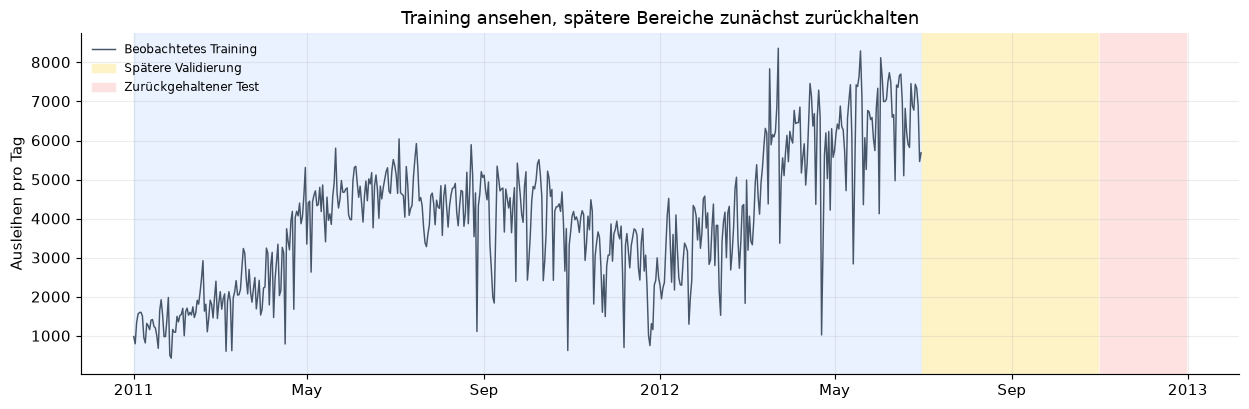

In [3]:
fig,ax=plt.subplots(figsize=(12,4))
ax.plot(train_roh,color=FARBEN["roh"],lw=1,label="Beobachtetes Training")
ax.axvspan(train_roh.index[0],train_ende,color=FARBEN["train"],alpha=0.6)
ax.axvspan(train_ende+pd.Timedelta(days=1),val_ende,color=FARBEN["val"],label="Spätere Validierung")
ax.axvspan(val_ende+pd.Timedelta(days=1),y.index[-1],color=FARBEN["test"],label="Zurückgehaltener Test")
ax.set(ylabel="Ausleihen pro Tag",title="Training ansehen, spätere Bereiche zunächst zurückhalten")
zeitachse(ax); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

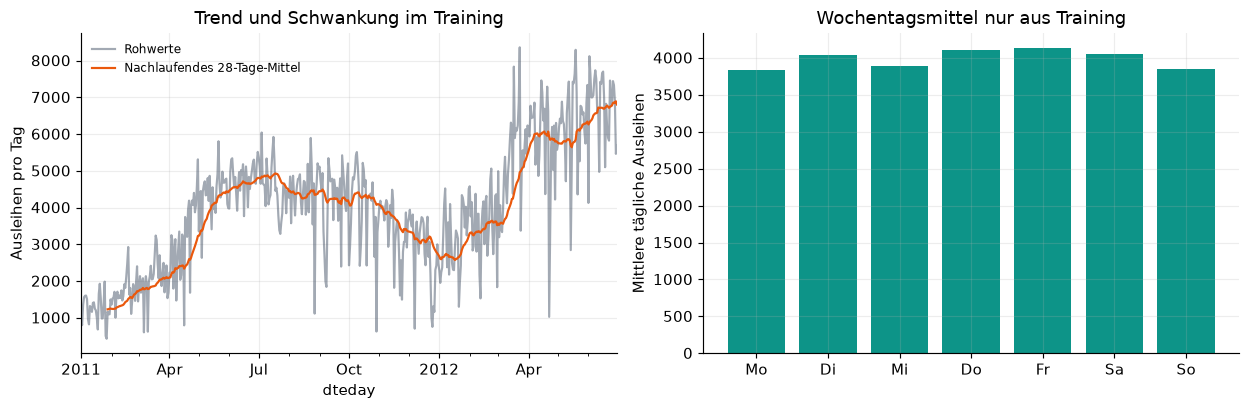

In [4]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
train_roh.plot(ax=axes[0],color=FARBEN["roh"],alpha=0.5,label="Rohwerte")
train_roh.rolling(28,min_periods=28).mean().plot(ax=axes[0],color=FARBEN["trend"],label="Nachlaufendes 28-Tage-Mittel")
axes[0].set(title="Trend und Schwankung im Training",ylabel="Ausleihen pro Tag")
zeitachse(axes[0]); axes[0].legend(fontsize=8)
profil=train_roh.groupby(train_roh.index.dayofweek).mean()
axes[1].bar(["Mo","Di","Mi","Do","Fr","Sa","So"],profil,color=FARBEN["saison"])
axes[1].set(title="Wochentagsmittel nur aus Training",ylabel="Mittlere tägliche Ausleihen")
plt.tight_layout(); plt.show()

## 2. Einfache, verfügbare Merkmale

Wir nutzen Lags 1, 7 und 14 Tage, nach hinten gerichtete Rollstatistiken und zyklische Kalendermerkmale. Ein Sinus/Cosinus-Paar stellt beispielsweise Dezember und Januar als Nachbarn dar. Es garantiert kein passendes Modell.

Alle Features sind vor Tagesbeginn verfügbar. Wir wählen hier bewusst keine Wettereingaben: gemessenes Wetter des Zieltags ist vorab unbekannt; ein echter Wetterforecast wäre eine andere, zusätzliche Datenquelle.

In [5]:
X,ziel=lag_tabelle(y,lags=(1,7,14),fenster=(7,28))
# Stundenmerkmale sind bei täglichem Raster konstant und werden entfernt.
X=X.drop(columns=["stunde_sin","stunde_cos"])
X_train=X.loc[:train_ende]; y_train=ziel.loc[X_train.index]
X_val=X.loc["2012-07-01":val_ende]; y_val=ziel.loc[X_val.index]
X_test=X.loc["2012-11-01":]; y_test=ziel.loc[X_test.index]
print("Nutzbare Zeilen Training/Validierung/Test:",len(X_train),len(X_val),len(X_test))
display(X_train.head(3).round(2))

Nutzbare Zeilen Training/Validierung/Test: 519 123 61


,lag_1,lag_7,lag_14,mittel_7,std_7,mittel_28,std_28,wochentag_sin,wochentag_cos,tag_im_jahr_sin,tag_im_jahr_cos
dteday,,,,,,,,,,,
2011-01-29,1167.0,981.0,1248.0,1067.43,533.49,1231.93,387.41,-0.97,-0.22,0.48,0.88
2011-01-30,1098.0,986.0,1204.0,1084.14,532.17,1235.96,385.33,-0.78,0.62,0.49,0.87
2011-01-31,1096.0,1416.0,1000.0,1099.86,530.41,1246.50,376.94,0.00,1.00,0.51,0.86


## 3. Kleine Modellwahl auf dem Validierungsblock

Wir vergleichen drei Ridge-Stärken und einen vorab festgelegten kleinen Boosting-Kandidaten. Auswahlkriterium: Validierungs-MAE. RMSE gewichtet größere Fehler stärker. MAPE verwenden wir nicht, weil kleine bzw. Nullwerte sie problematisch machen können.

Die Validierung ist rollend pro Tag: gestern gemessene Validierungswerte dürfen heute als Lags verwendet werden. Die Modellparameter ändern sich innerhalb des Blocks nicht.

In [6]:
kandidaten={f"Ridge alpha={a}":make_pipeline(StandardScaler(),Ridge(alpha=a)) for a in [1,10,100]}
kandidaten["Kleines Boosting"]=HistGradientBoostingRegressor(max_iter=150,max_leaf_nodes=15,
    learning_rate=0.06,l2_regularization=5,random_state=42)
val_prognosen={"Gestern":X_val.lag_1,"Vorwoche":X_val.lag_7}
for name,modell in kandidaten.items():
    modell.fit(X_train,y_train)
    val_prognosen[name]=modell.predict(X_val)
val_ergebnisse=metriken(y_val,val_prognosen)
display(val_ergebnisse.sort_values("MAE").round(1))
bester_name=val_ergebnisse.loc[list(kandidaten)].MAE.idxmin()
print("Gewähltes lernendes Modell:",bester_name)

,MAE,RMSE
Modell,,
Gestern,868.1,1300.5
Ridge alpha=1,936.8,1190.9
Ridge alpha=10,939.4,1193.4
Vorwoche,952.8,1463.6
Ridge alpha=100,974.8,1225.7
Kleines Boosting,1152.5,1398.9


Gewähltes lernendes Modell: Ridge alpha=1


**Modellwahl richtig lesen:** Wir vergleichen den besten *lernenden* Kandidaten mit den Baselines. Wenn eine Baseline bereits auf der Validierung den kleinsten MAE hat, wäre sie nach diesem Kriterium die bevorzugte Lösung. Das lernende Modell wird hier trotzdem als Vergleich ausgewertet; höhere Komplexität garantiert keinen Vorteil.

## 4. Finaler Test und Fehler über die Zeit

Erst jetzt fitten wir den gewählten Kandidaten auf Training plus Validierung und zeigen die tatsächlichen Testwerte. Die Testperiode umfasst nur zwei Monate: Das Resultat beschreibt diesen Zeitraum, nicht automatisch ein ganzes Jahr oder einen anderen Anbieter.

Alle Modelle und Baselines nutzen dasselbe rollende Ein-Tages-Protokoll. Der Vorwochenwert kann im Verlauf des Tests ebenfalls aus einer bereits abgeschlossenen Testwoche stammen.

,MAE,RMSE
Modell,,
Gestern,783.5,1035.4
Ridge alpha=1,856.6,1141.6
Vorwoche,1486.7,1968.9


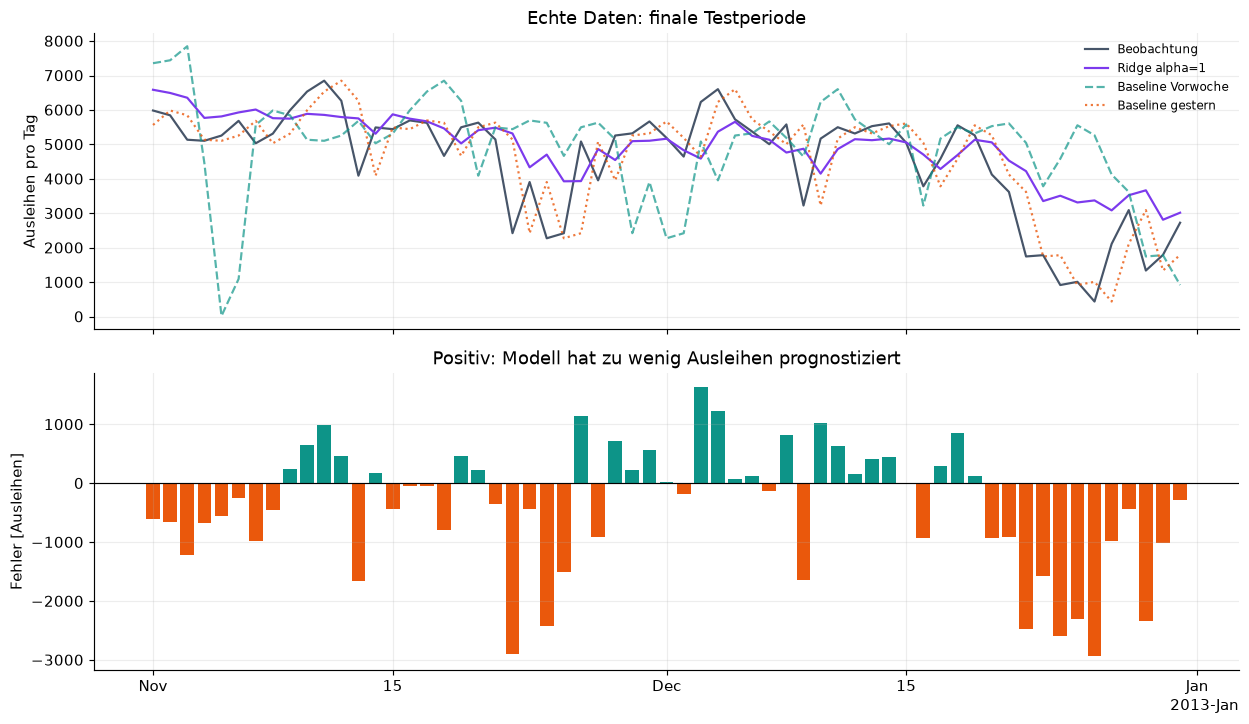

In [7]:
final=clone(kandidaten[bester_name]).fit(pd.concat([X_train,X_val]),pd.concat([y_train,y_val]))
vorhersage=pd.Series(final.predict(X_test),index=X_test.index)
prognosen={"Gestern":X_test.lag_1,"Vorwoche":X_test.lag_7,bester_name:vorhersage}
test_ergebnisse=metriken(y_test,prognosen)
display(test_ergebnisse.sort_values("MAE").round(1))
fig,axes=plt.subplots(2,1,figsize=(12,7),sharex=True)
axes[0].plot(y_test,color=FARBEN["roh"],label="Beobachtung")
axes[0].plot(vorhersage,color=FARBEN["prognose"],label=bester_name)
axes[0].plot(X_test.lag_7,color=FARBEN["saison"],ls="--",alpha=0.7,label="Baseline Vorwoche")
axes[0].plot(X_test.lag_1,color="#ea580c",ls=":",alpha=0.8,label="Baseline gestern")
axes[0].set(title="Echte Daten: finale Testperiode",ylabel="Ausleihen pro Tag"); axes[0].legend(fontsize=8)
fehler=y_test-vorhersage
axes[1].bar(fehler.index,fehler,color=np.where(fehler>=0,"#0d9488","#ea580c"))
axes[1].axhline(0,color="black",lw=0.8)
axes[1].set(title="Positiv: Modell hat zu wenig Ausleihen prognostiziert",ylabel="Fehler [Ausleihen]")
zeitachse(axes[-1]); plt.tight_layout(); plt.show()

In [8]:
detail=pd.DataFrame({"Ist":y_test,"Prognose":vorhersage,"Absoluter Fehler":fehler.abs()})
display(detail.nlargest(5,"Absoluter Fehler").round(1))
print("Keine nachträgliche Modellanpassung an diese Testfehler.")

,Ist,Prognose,Absoluter Fehler
dteday,,,
2012-12-26,441.0,3376.3,2935.3
2012-11-22,2425.0,5319.4,2894.4
2012-12-24,920.0,3512.0,2592.0
2012-12-22,1749.0,4225.2,2476.2
2012-11-24,2277.0,4706.2,2429.2


Keine nachträgliche Modellanpassung an diese Testfehler.


## Diskussion
1. Übertrifft das lernende Modell beide Baselines? Falls nicht: Ein einfaches Modell kann die bessere Wahl sein.
2. Was unterscheidet die Fehler großer Nachfragesprünge von normalen Tagen?
3. Weshalb wären `casual`, `registered` und tatsächliche Wetterdaten des Zieltags problematisch?
4. Wie müsste ein fairer Vergleich für eine Vorhersage der gesamten nächsten Woche aussehen?

Weitere Herkunfts- und Lizenzangaben sowie reproduzierbarer Download: `daten/README.md`.